# Hier-COS Output Analysis

This notebook analyzes training/test artifacts in `/scratch/g.saggini1/outputs/` and compares Hier-COS variants across datasets.

Default setup:
- baseline run per dataset: `hiercos_<dataset>` (`model.loss=kl_reg`)
- CE ablation variants: `hiercos_<dataset>_ce_equal`, `_ce_kl_leaf`, `_ce_kl_coarse`

It includes:
- validation curves for `FPA`, `weighted AP`, `TICE`, and `AHD`,
- per-level validation top-down/independent accuracy curves,
- training loss comparisons (`total`, `level_ce`, `kl`, `reg`, and `loss_level_*` when available),
- optional projection/gradient diagnostics when those metrics are present in logs,
- final test comparison tables with deltas versus dataset baseline.


In [51]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HierCosAnalysis,
    HCastAnalysisConfig as HierCosAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [52]:
INCLUDE_BASELINES = True
BASELINE_COLOR = "#1fb46c"

BASELINE_BY_DATASET = {
    'cifar100': {'run_dir': 'hiercos_cifar100', 'label': 'Hier-COS (kl_reg)'},
    'cub200': {'run_dir': 'hiercos_cub200', 'label': 'Hier-COS (kl_reg)'},
    'fgvcaircraft': {'run_dir': 'hiercos_aircraft', 'label': 'Hier-COS (kl_reg)'},
}

MANUAL_RUNS = [
    # CIFAR100
    {'run_dir': 'hiercos_cifar100_ce_equal', 'label': 'Hier-COS CE equal'},
    {'run_dir': 'hiercos_cifar100_ce_kl_leaf', 'label': 'Hier-COS CE kl_leaf'},
    {'run_dir': 'hiercos_cifar100_ce_kl_coarse', 'label': 'Hier-COS CE kl_coarse'},

    # CUB200
    {'run_dir': 'hiercos_cub200_ce_equal', 'label': 'Hier-COS CE equal'},
    {'run_dir': 'hiercos_cub200_ce_kl_leaf', 'label': 'Hier-COS CE kl_leaf'},
    {'run_dir': 'hiercos_cub200_ce_kl_coarse', 'label': 'Hier-COS CE kl_coarse'},

    # Aircraft
    {'run_dir': 'hiercos_aircraft_ce_equal', 'label': 'Hier-COS CE equal'},
    {'run_dir': 'hiercos_aircraft_ce_kl_leaf', 'label': 'Hier-COS CE kl_leaf'},
    {'run_dir': 'hiercos_aircraft_ce_kl_coarse', 'label': 'Hier-COS CE kl_coarse'},
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [53]:
config = HierCosAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HierCosAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_ce_equal
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_ce_kl_leaf
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_ce_kl_coarse
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_ce_equal
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_ce_kl_leaf
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_ce_kl_coarse
[cifar-100] Hier-COS (kl_reg): epochs=100, best_td_epoch=91, best_ind_epoch=91, baseline
[cifar-100] Hier-COS CE equal: epochs=100, best_td_epoch=99, best_ind_epoch=96
[cifar-100] Hier-COS CE kl_leaf: epochs=100, best_td_epoch=91, best_ind_epoch=91
[cifar-100] Hier-COS CE kl_coarse: epochs=52, best_td_epoch=51, best_ind_epoch=51


## Hier-COS Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


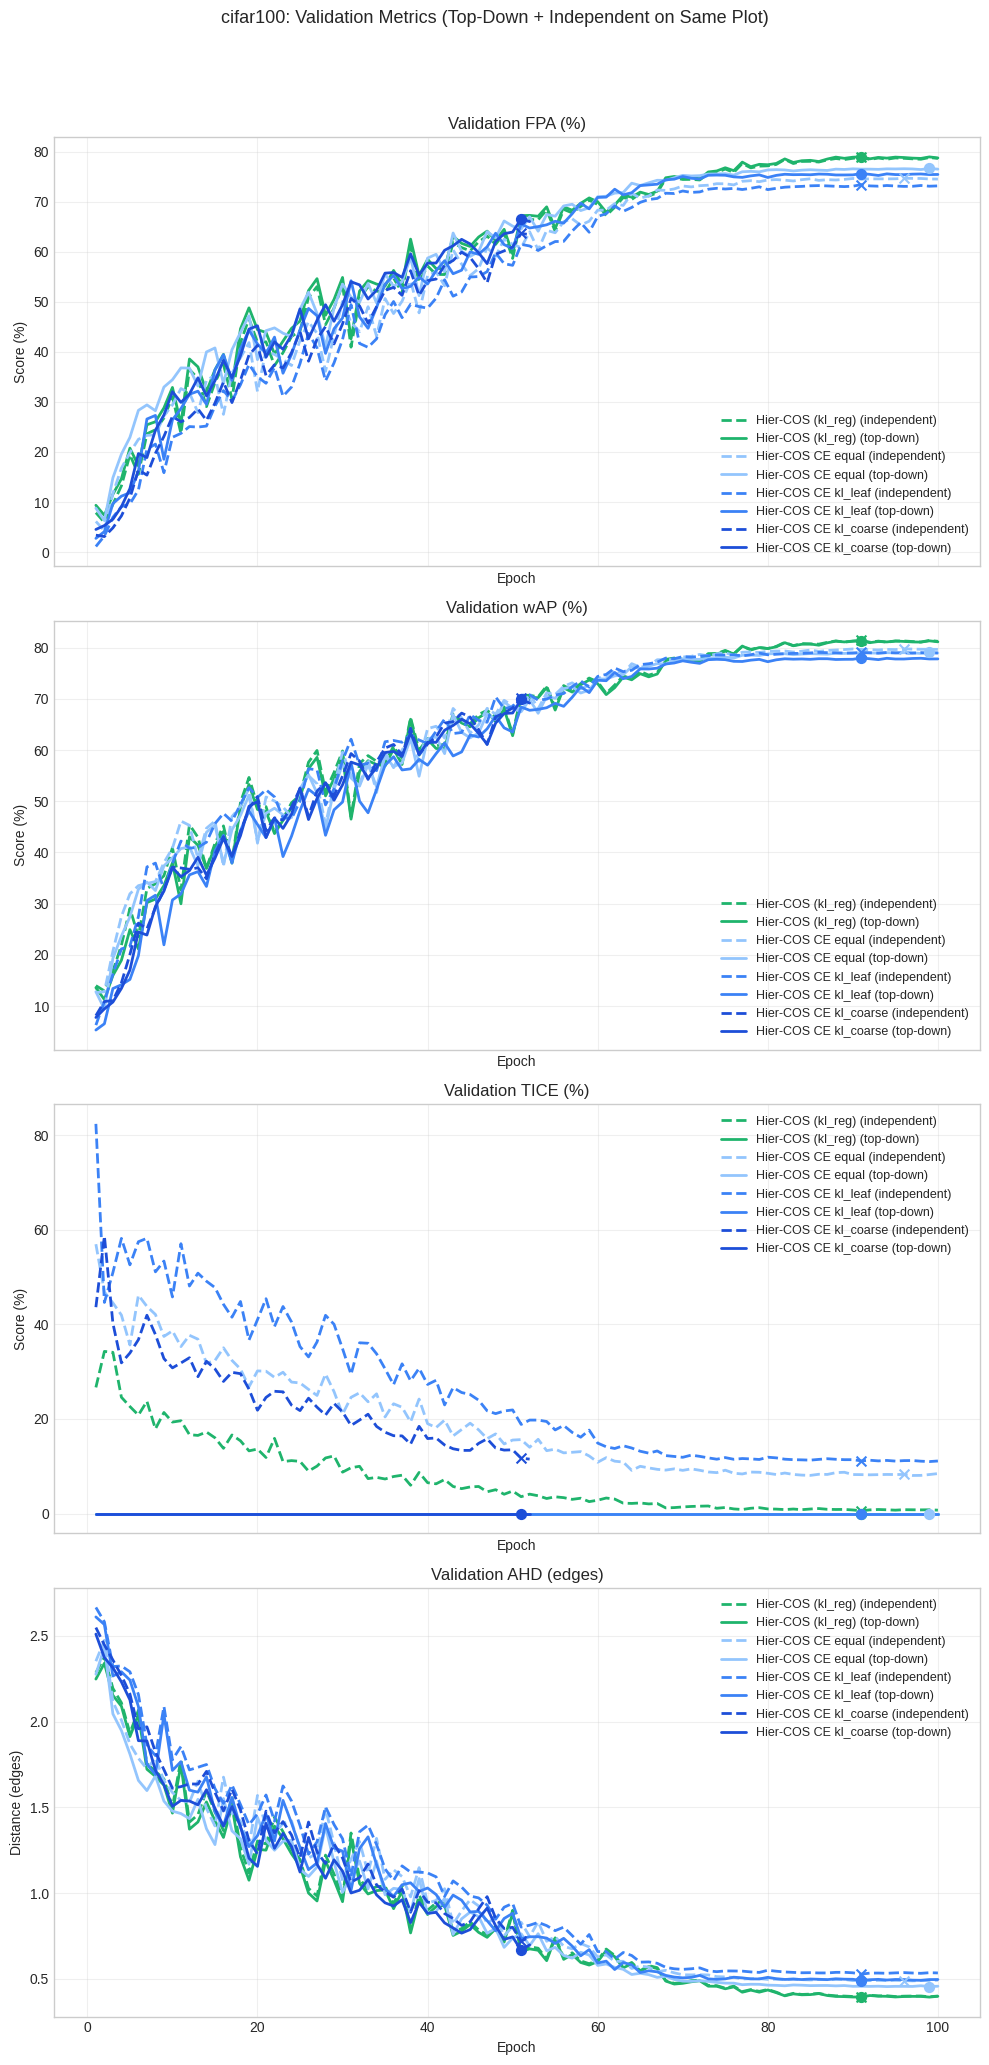

In [54]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (If Available)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha`
- `proj_constraint_strength`
- `proj_temperature`
- `proj_mode_intrinsic_soft`

For standard Hier-COS runs these keys may be absent; in that case the section prints a per-dataset skip message.


In [55]:
analysis.plot_projection_diagnostics()


[cifar100] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares training losses between runs for aggregate losses (`total`, `level_ce`, `kl`, `reg`) and per-level losses (`loss_level_*`, when available).


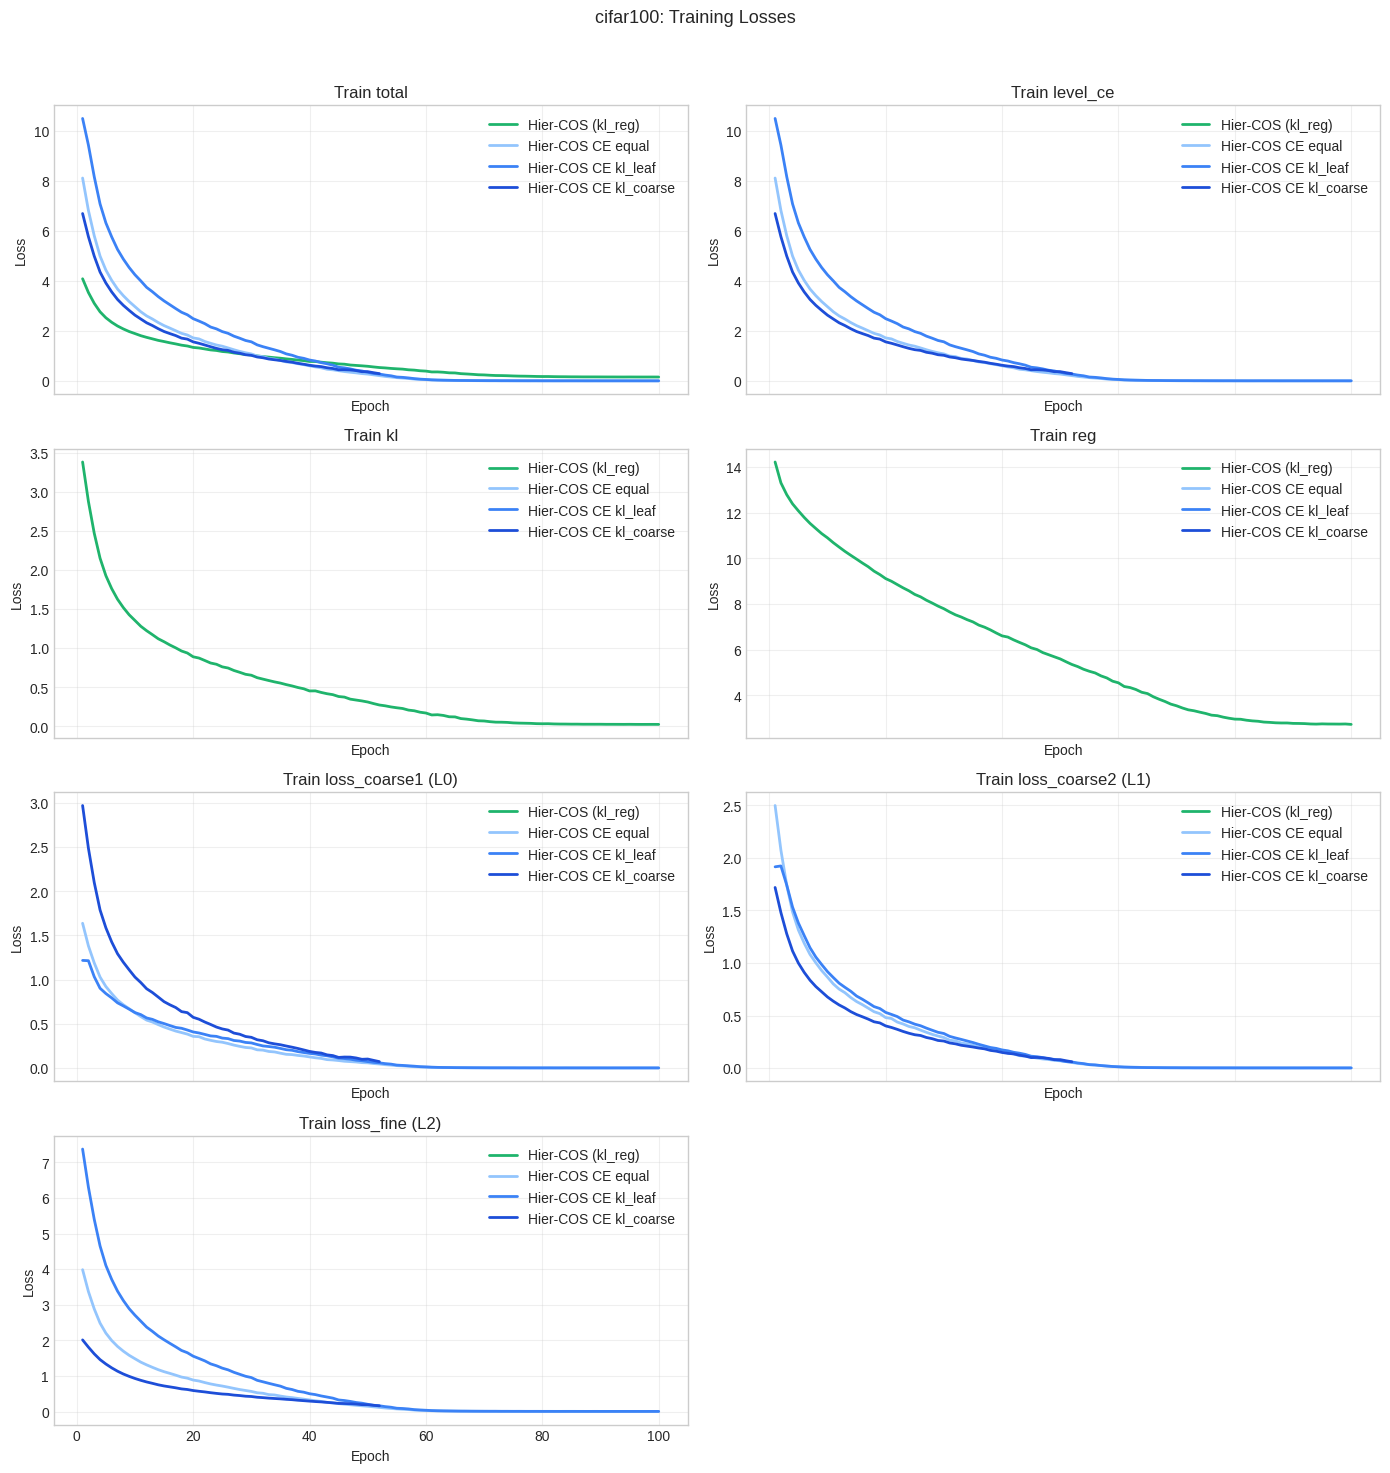

In [56]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'level_ce', 'kl', 'reg'])


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



[cifar100] No per-level train losses for Hier-COS (kl_reg)


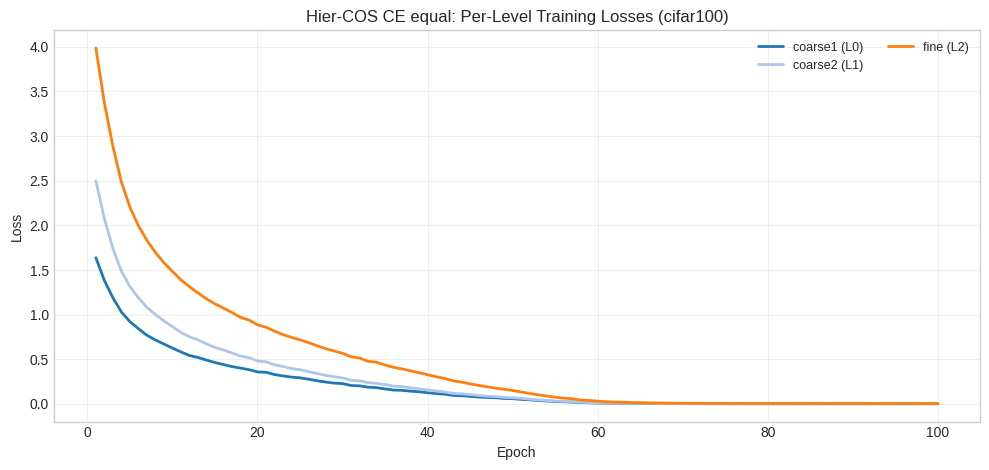

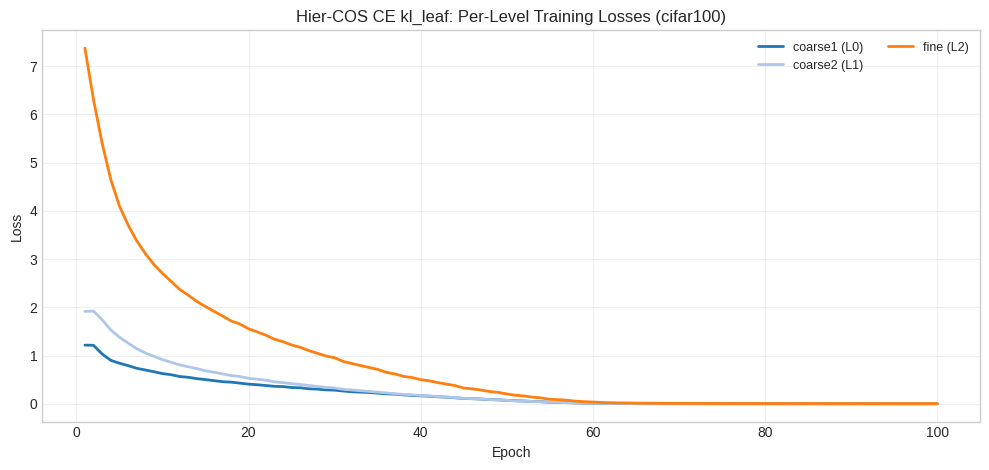

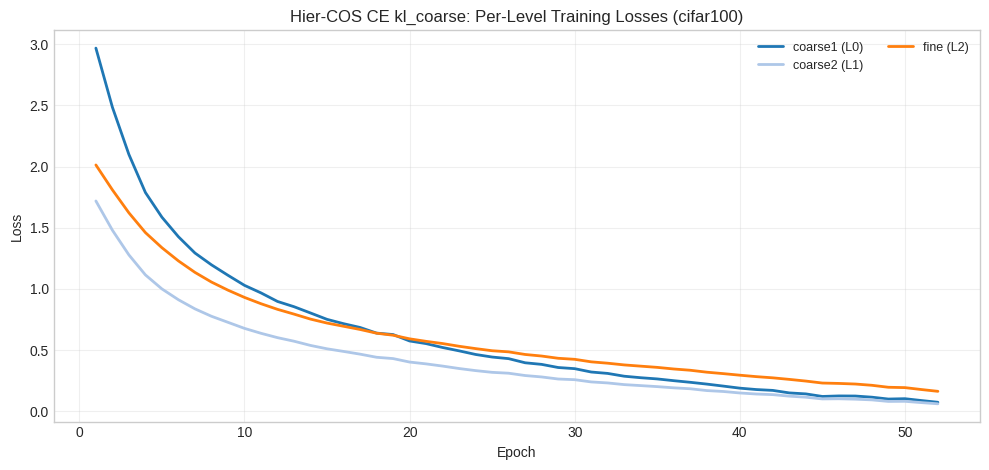

In [57]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and optional projection diagnostics stored in `train_metrics` for each epoch.

For Hier-COS, many of these metrics are available only in CE/diagnostic-focused runs. If unavailable, corresponding plots are skipped automatically.


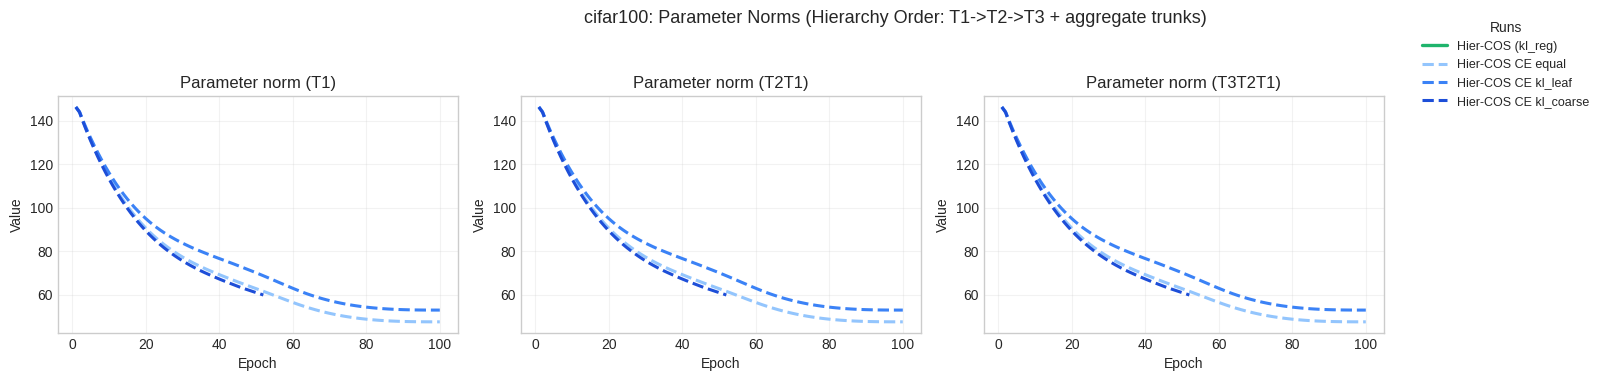

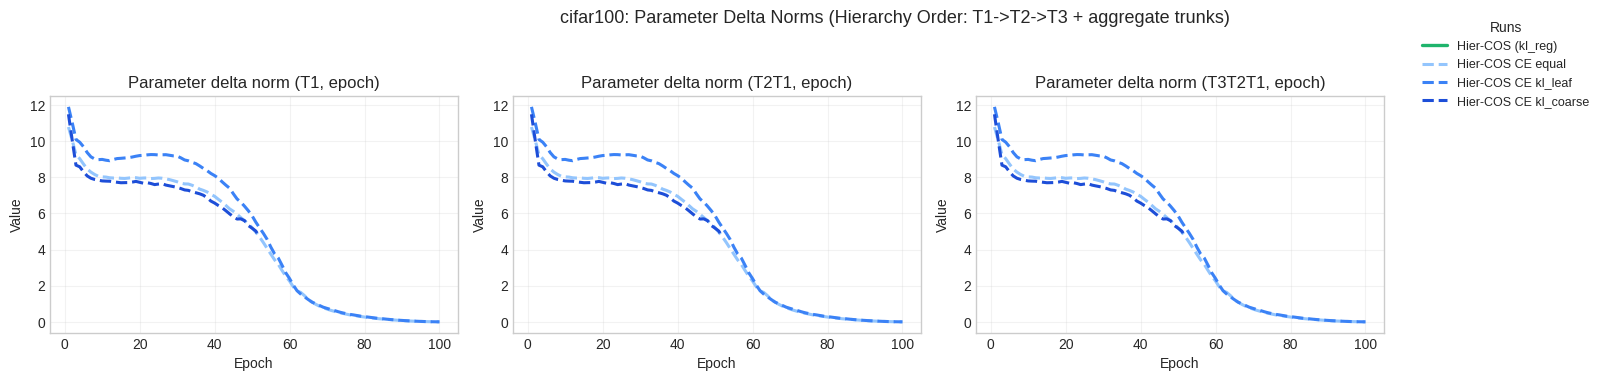

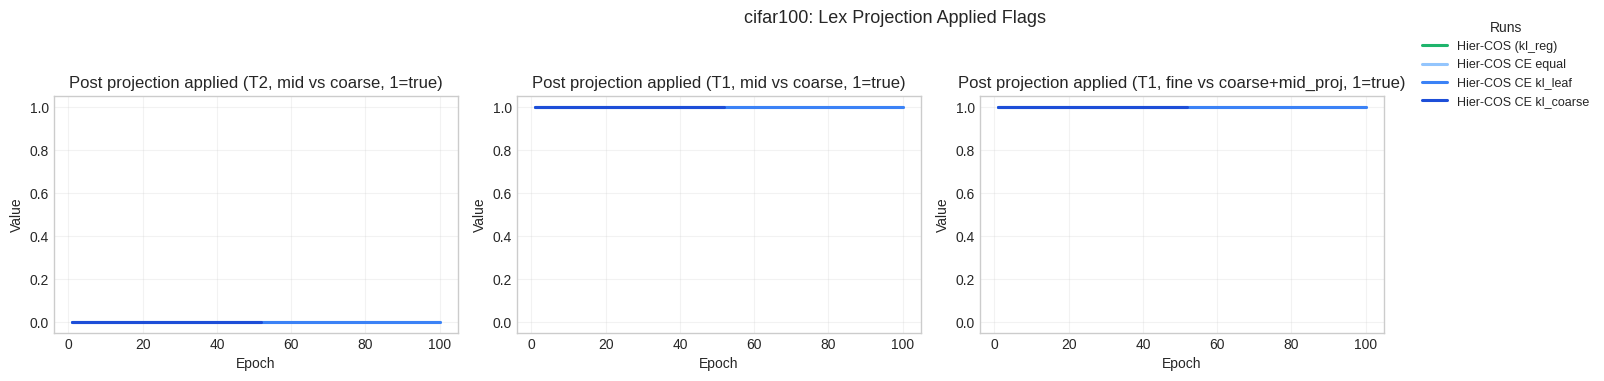

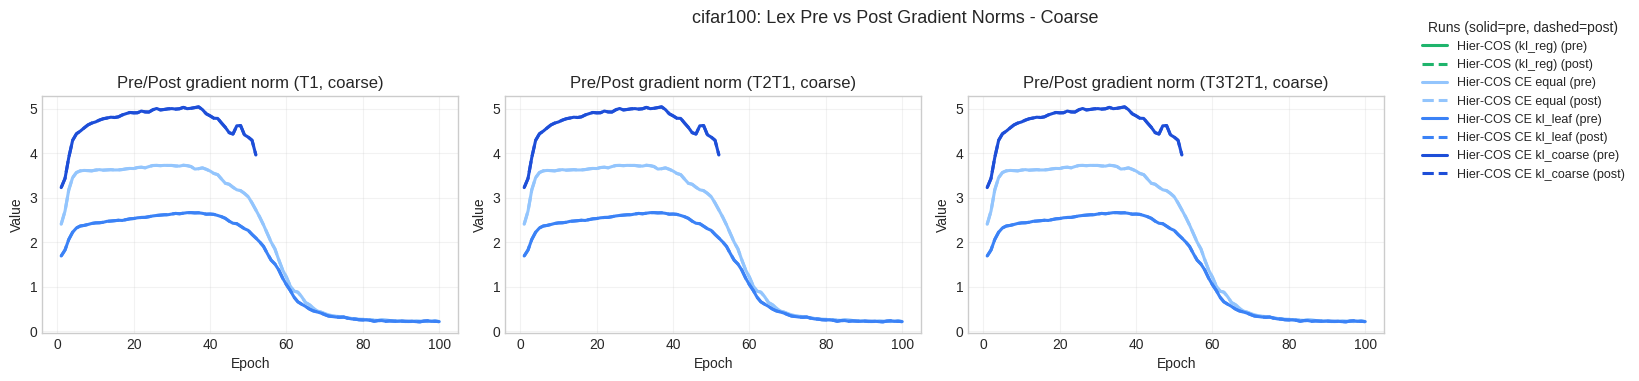

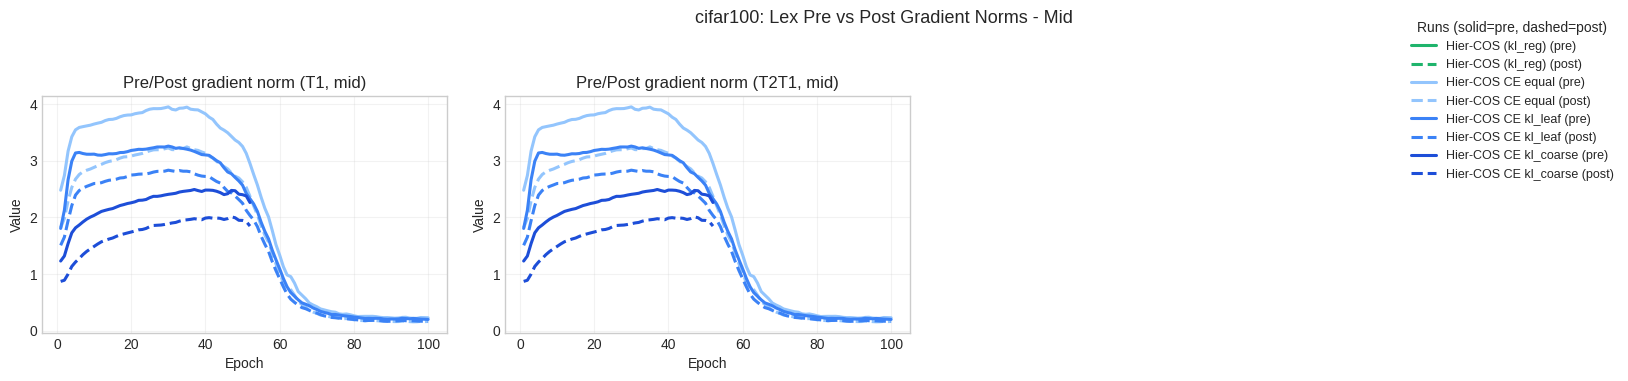

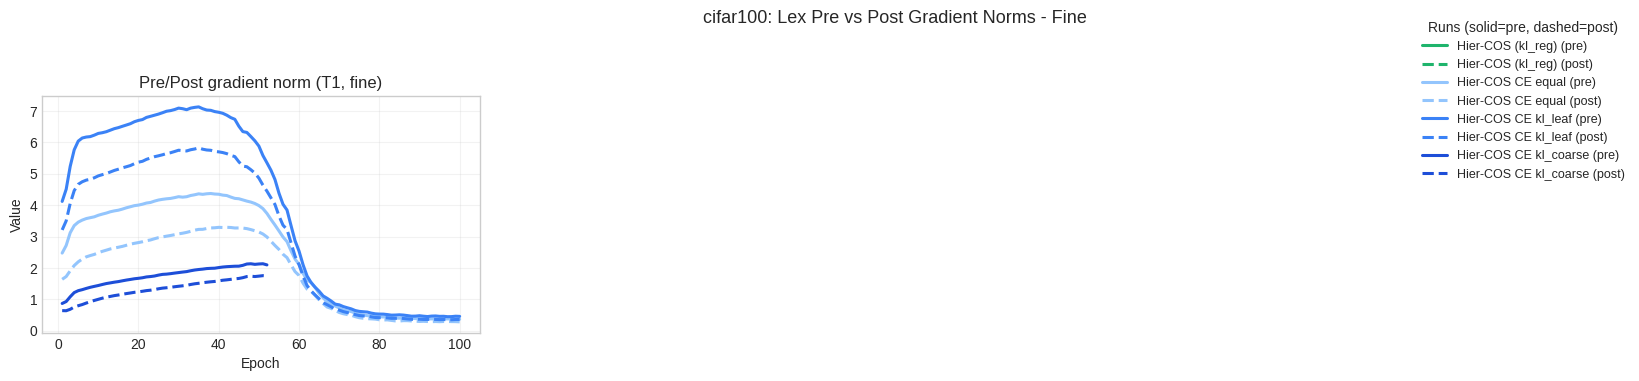

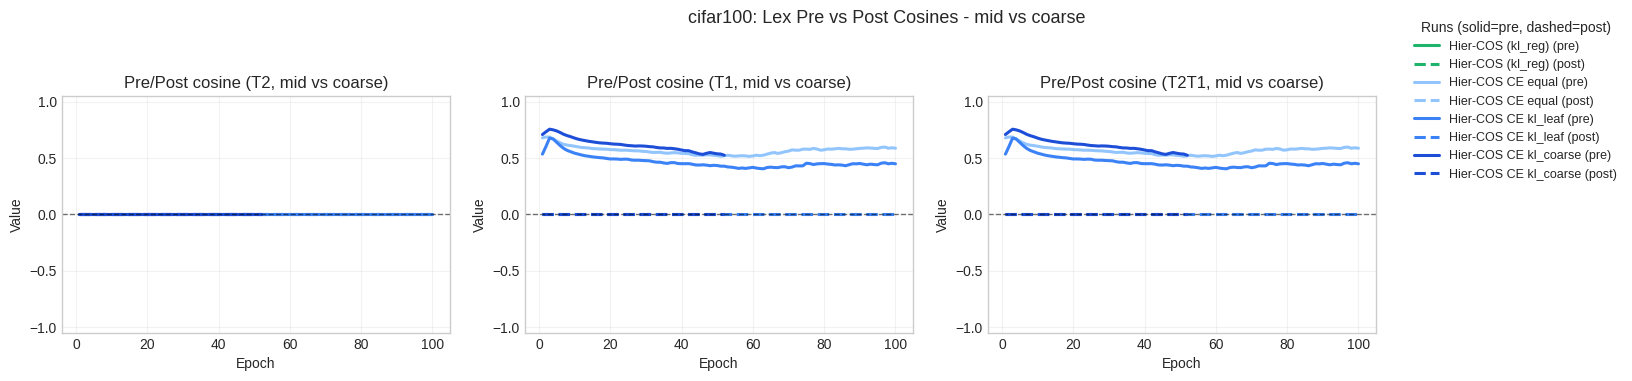

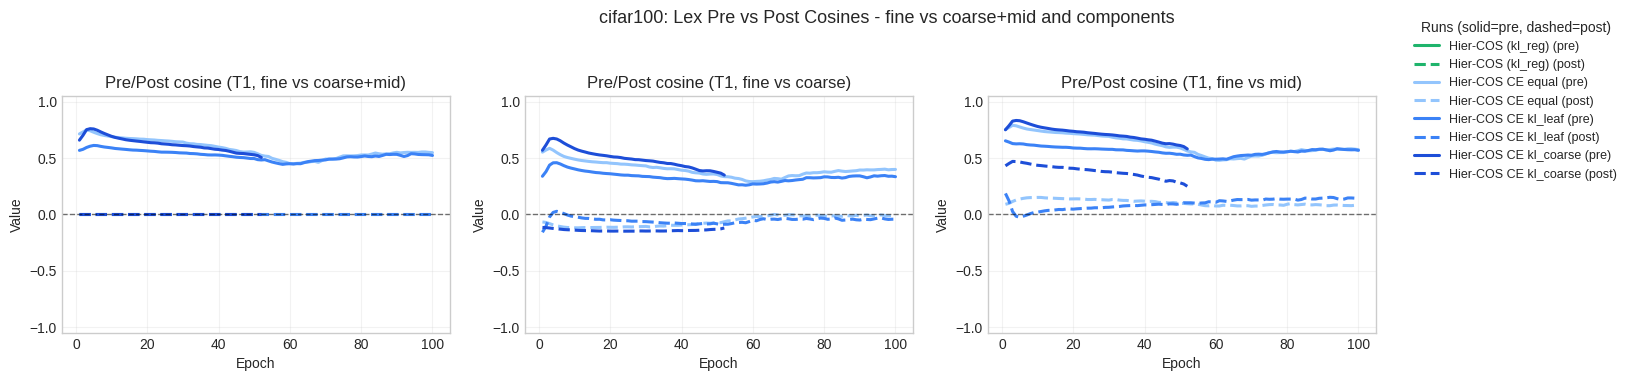

In [58]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

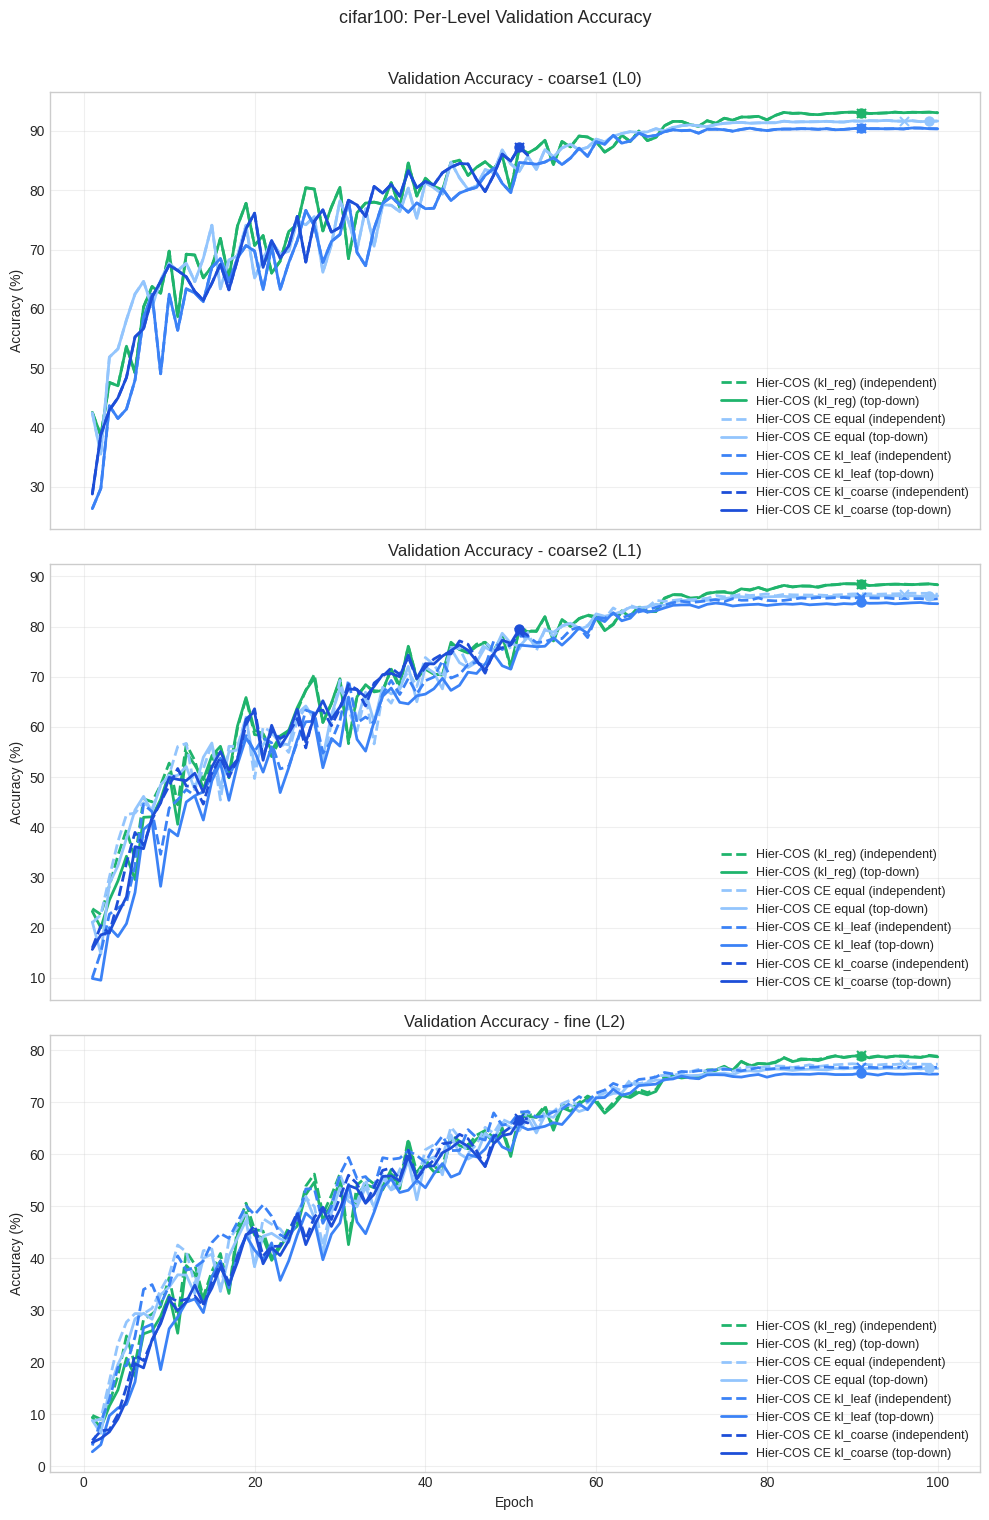

In [59]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset (typically the `kl_reg` baseline).


In [60]:
analysis.show_final_test_tables()


### Dataset: `cifar100`
Baseline run: **Hier-COS (kl_reg)**

| Metric | Hier-COS (kl_reg) | Hier-COS CE equal | Hier-COS CE kl_leaf | Hier-COS CE kl_coarse |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 91/91 | 99/96 | 91/91 | 51/51 |
| FPA independent ↑ | **77.27%** | <u>74.42% (-2.85 pp)</u> | 72.75% (-4.53 pp) | n/a |
| FPA top-down ↑ | **77.47%** | <u>76.53% (-0.94 pp)</u> | 75.60% (-1.87 pp) | n/a |
| wAP independent ↑ | **79.88%** | <u>79.26% (-0.62 pp)</u> | 78.43% (-1.45 pp) | n/a |
| wAP top-down ↑ | **79.76%** | <u>78.88% (-0.88 pp)</u> | 77.88% (-1.88 pp) | n/a |
| TICE independent ↓ | **1.17%** | <u>8.86% (+7.69 pp)</u> | 11.80% (+10.63 pp) | n/a |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | n/a |
| AHD independent ↓ | **0.451** | <u>0.504 (+0.053)</u> | 0.551 (+0.100) | n/a |
| AHD top-down ↓ | **0.448** | <u>0.467 (+0.019)</u> | 0.500 (+0.052) | n/a |
| Acc independent coarse1 (L0) ↑ | **91.15%** | <u>91.06% (-0.09 pp)</u> | 89.99% (-1.15 pp) | n/a |
| Acc top-down coarse1 (L0) ↑ | **91.15%** | <u>91.07% (-0.08 pp)</u> | 89.99% (-1.15 pp) | n/a |
| Acc independent coarse2 (L1) ↑ | **86.65%** | <u>85.90% (-0.75 pp)</u> | 84.89% (-1.76 pp) | n/a |
| Acc top-down coarse2 (L1) ↑ | **86.62%** | <u>85.75% (-0.87 pp)</u> | 84.44% (-2.18 pp) | n/a |
| Acc independent fine (L2) ↑ | **77.62%** | <u>76.98% (-0.64 pp)</u> | 76.21% (-1.41 pp) | n/a |
| Acc top-down fine (L2) ↑ | **77.47%** | <u>76.53% (-0.94 pp)</u> | 75.60% (-1.87 pp) | n/a |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
